# Heart Disease Prediction -  Notebook

## Step 1: Import the libraries we need


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Load the data

We have three files in this folder:
- `train.csv` — has the answer column `Heart Disease` (Presence/Absence). We use this to teach the model.
- `test.csv` — does **not** have the answer. We will predict it.
- `sample_submission.csv` — shows the exact format Kaggle (or whoever set this up) expects our predictions in.

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("sample_submission shape:", sample_submission.shape)

train shape: (630000, 15)
test shape: (270000, 14)
sample_submission shape: (270000, 2)


## Step 3: Explore the data

Before training any model, always **look at your data first**. Let's check:
- What the columns look like (`.head()`)
- The data types of each column (`.info()`)
- Whether anything is missing (`.isna().sum()`)
- How balanced our target column is (`.value_counts()`)

In [3]:
train_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [5]:
# Check for missing values in every column
train_df.isna().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [6]:
# Good news: this dataset has no missing values, so we don't need to fill/drop anything.

# Let's see how many people have heart disease vs not (our target column)
train_df["Heart Disease"].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

### Missing values — visualized

The counts above already told us there are no missing values, but a quick visual check is a standard part of EDA and makes it obvious at a glance. We plot a heatmap of `.isna()` (True/False for every cell) on a random sample of rows — a single solid color means "nothing missing."

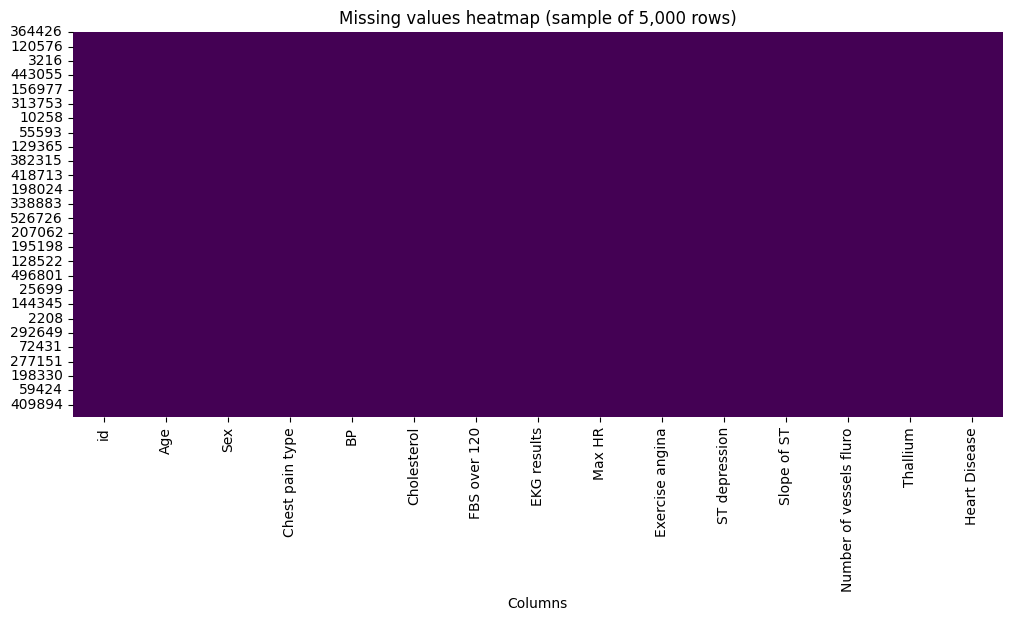

In [7]:
plt.figure(figsize=(12, 5))
sns.heatmap(train_df.sample(5000, random_state=42).isna(), cbar=False, cmap="viridis")
plt.title("Missing values heatmap (sample of 5,000 rows)")
plt.xlabel("Columns")
plt.show()

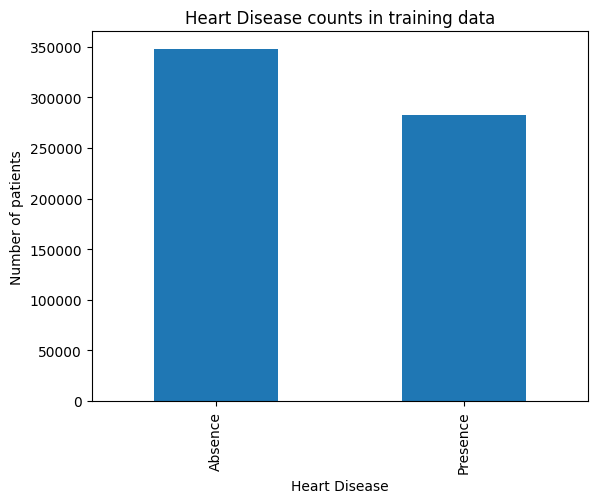

In [8]:
# A quick bar chart of the same thing - visuals help you understand balance at a glance
train_df["Heart Disease"].value_counts().plot(kind="bar", title="Heart Disease counts in training data")
plt.xlabel("Heart Disease")
plt.ylabel("Number of patients")
plt.show()

### Correlation heatmap

This shows how strongly each numeric feature relates to the others, and — in the last row/column — to the target (`Heart Disease`, temporarily encoded as 1/0 just for this chart). Values close to +1 or -1 mean a strong relationship; values close to 0 mean little to no linear relationship.

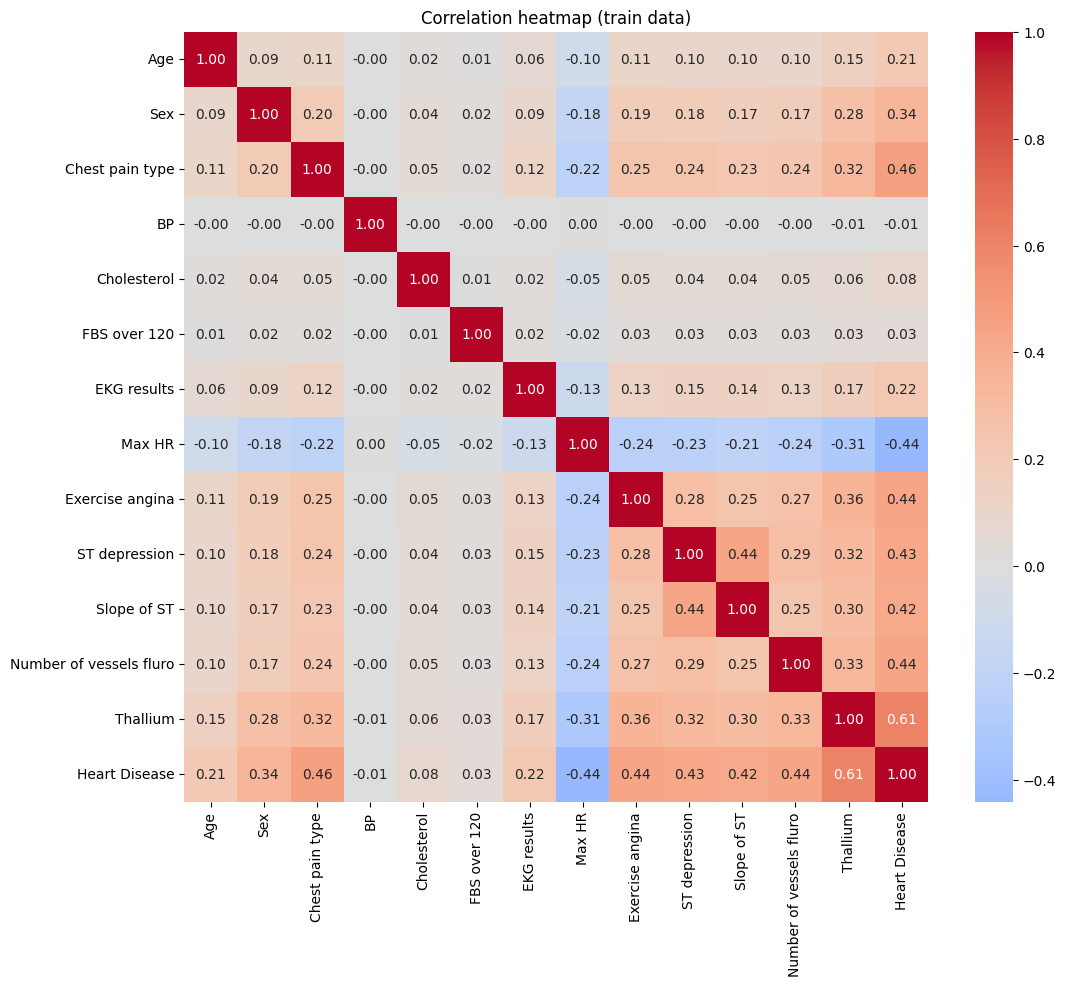

In [9]:
corr_df = train_df.drop(columns=["id"]).copy()
corr_df["Heart Disease"] = corr_df["Heart Disease"].map({"Presence": 1, "Absence": 0})

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap (train data)")
plt.show()

### Feature distributions — histograms

Histograms show the shape of each feature: is it roughly symmetric (like `Age`), skewed, or mostly one value (like `FBS over 120`, which is 0/1)? This helps spot skew and unusual spreads before modeling.

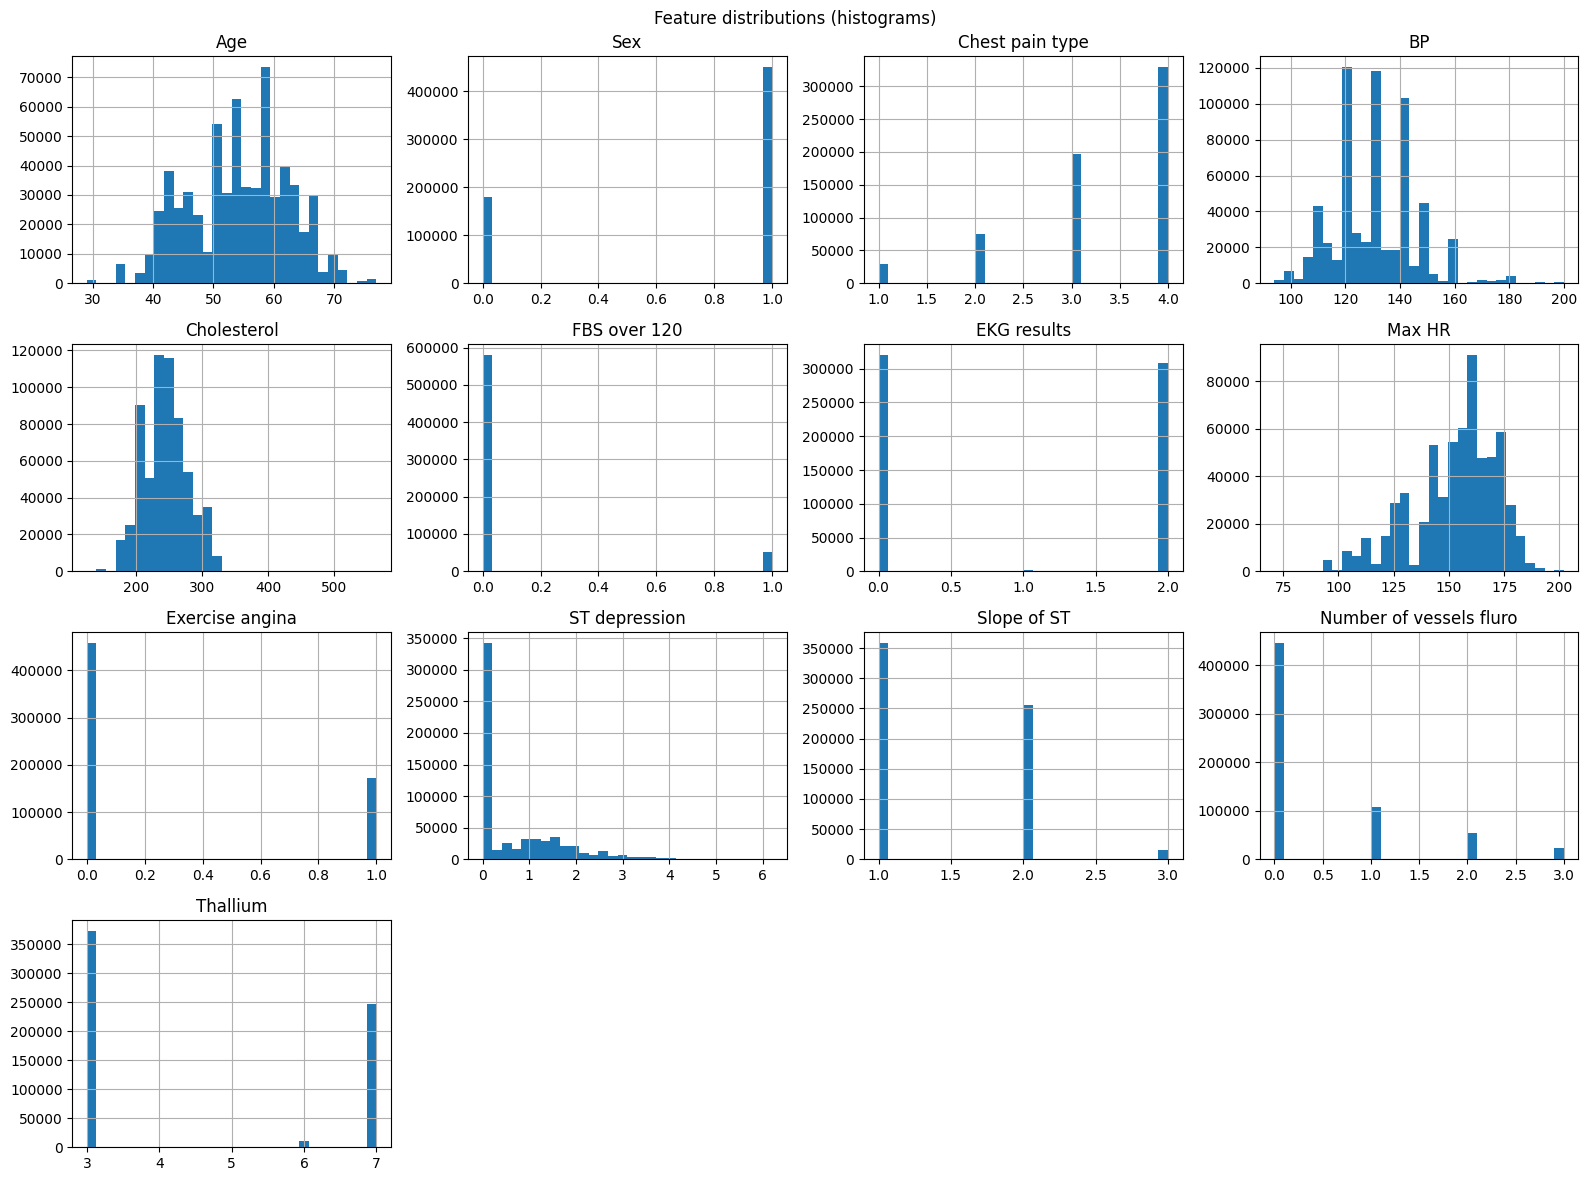

In [10]:
numeric_cols = [c for c in train_df.columns if c not in ["id", "Heart Disease"]]

train_df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Feature distributions (histograms)")
plt.tight_layout()
plt.show()

## Step 4: Prepare the data for the model

Machine learning models need **numbers**, not text. Our target column `Heart Disease` currently says `"Presence"` / `"Absence"`. We'll convert it to `1` / `0` (this matches the format in `sample_submission.csv`, which already uses 0/1).

We also separate:
- **X** = the input features (everything the model is allowed to look at, e.g. Age, BP, Cholesterol...)
- **y** = the target (what we want to predict: Heart Disease)

Note: the `id` column is just a row identifier, not useful information for prediction, so we drop it from X.

In [8]:
# Convert the text target into 0/1
# Presence -> 1 (has heart disease), Absence -> 0 (no heart disease)
train_df["target"] = train_df["Heart Disease"].map({"Presence": 1, "Absence": 0})

# Sanity check: this should show no NaN values, meaning every row mapped correctly
print(train_df["target"].isna().sum(), "unmapped rows (should be 0)")

# X = features (drop id, the old text target, and the new target column)
X = train_df.drop(columns=["id", "Heart Disease", "target"])
y = train_df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

0 unmapped rows (should be 0)
X shape: (630000, 13)
y shape: (630000,)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3


## Step 5: Split into training and validation sets

We never train and test on the exact same data — that would be like grading a student on the exact questions they memorized. Instead we hold back a portion (here, 20%) as a **validation set** to check how well the model generalizes to unseen data.

- `X_train`, `y_train` — used to teach the model
- `X_valid`, `y_valid` — used only to check the model's performance afterward

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,      # 20% of data held back for validation
    random_state=42,    # fixed seed so results are reproducible every run
    stratify=y          # keeps the same Presence/Absence ratio in both splits
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (504000, 13)
X_valid: (126000, 13)


## Step 6: Train our model — Random Forest

A Random Forest builds many decision trees on random subsets of the data and features, then averages their votes. It's beginner-friendly (few settings to worry about), handles numeric medical data well, and doesn't need feature scaling.

In [ ]:

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=42, 
    n_jobs=-1)
rf.fit(X_train, y_train)  

print("Random Forest trained.")

Random Forest trained.


## Step 7: Evaluate the model

We check performance on the **validation set** (data the model has never seen during training):
- **Accuracy** — % of predictions that were correct
- **Confusion matrix** — a table of correct vs incorrect predictions per class
- **Classification report** — precision, recall, and F1-score per class

In [11]:
rf_preds = rf.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, rf_preds))
print()
print("Confusion matrix:")
print(confusion_matrix(y_valid, rf_preds))
print()
print("Classification report:")
print(classification_report(y_valid, rf_preds, target_names=["Absence", "Presence"]))

Accuracy: 0.8870793650793651

Confusion matrix:
[[62911  6598]
 [ 7630 48861]]

Classification report:
              precision    recall  f1-score   support

     Absence       0.89      0.91      0.90     69509
    Presence       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



## Step 7b: Cross-validation — a more reliable accuracy estimate



In [ ]:
from sklearn.model_selection import cross_val_score

# Same settings as our baseline model, evaluated with 5-fold cross-validation on the full data
cv_model = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring="accuracy", n_jobs=-1)

print("Accuracy per fold:", cv_scores)
print(f"Mean accuracy: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

## Step 7c: Look at what the model gets wrong

Accuracy tells us *how often* the model is wrong, but not *why*. Let's pull out the validation rows the model misclassified (`rf_preds != y_valid`) and compare them to the rows it got right. If misclassified patients tend to have unusual or "borderline" feature values, that helps explain the model's mistakes and hints at what could be added (e.g., more data, or new features) to reduce them.

In [ ]:
# Mask: True where the model's prediction was wrong
wrong = rf_preds != y_valid.values

n_wrong = wrong.sum()
print(f"Misclassified: {n_wrong} / {len(y_valid)} rows ({n_wrong / len(y_valid):.2%})")

# False positives: predicted Presence (1) but actually Absence (0)
false_positives = (rf_preds == 1) & (y_valid.values == 0)
# False negatives: predicted Absence (0) but actually Presence (1)
false_negatives = (rf_preds == 0) & (y_valid.values == 1)
print(f"False positives (said Presence, was Absence): {false_positives.sum()}")
print(f"False negatives (said Absence, was Presence): {false_negatives.sum()}")

# Compare average feature values: misclassified rows vs correctly classified rows
comparison = pd.DataFrame({
    "misclassified_mean": X_valid[wrong].mean(),
    "correct_mean": X_valid[~wrong].mean(),
})
comparison["difference"] = comparison["misclassified_mean"] - comparison["correct_mean"]
comparison.sort_values("difference", key=abs, ascending=False)

## Step 8: Which features matter most?

Random Forest can tell us which columns it relied on most to make decisions. This is a great sanity check — e.g. we'd expect things like `Chest pain type`, `Thallium`, or `Number of vessels fluro` to matter for heart disease.

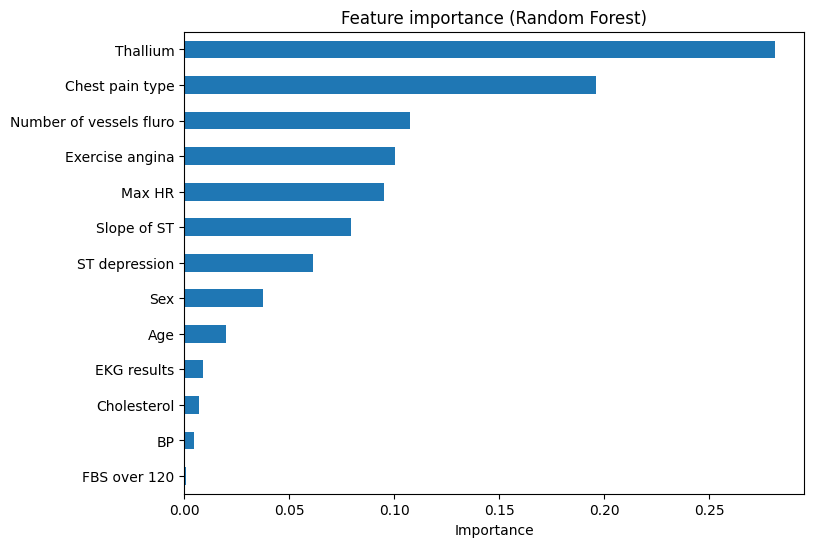

In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

importances.plot(kind="barh", figsize=(8, 6), title="Feature importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

## Step 8b: Hyperparameter tuning with GridSearchCV

Instead of guessing settings like `n_estimators` or `max_depth`, `GridSearchCV` tries **every combination** of a set of options we give it, using cross-validation to score each one fairly, and tells us which combination worked best.

This is thorough but slow: with the grid below (3 × 3 × 2 = 18 combinations) and 3-fold cross-validation, that's **54 separate Random Forest model fits** on ~504k rows. Expect this cell to take a while (potentially tens of minutes depending on your machine) — that's the trade-off for a more thorough search.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [1, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
)
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")

In [ ]:
# Sanity-check the tuned model on our held-out validation set (untouched by the grid search)
tuned_preds = grid_search.best_estimator_.predict(X_valid)
tuned_accuracy = accuracy_score(y_valid, tuned_preds)

print(f"Baseline validation accuracy (original settings): {accuracy_score(y_valid, rf_preds):.4f}")
print(f"Tuned validation accuracy (GridSearchCV best params):  {tuned_accuracy:.4f}")

## Step 9: Predict on `test.csv` and build the submission file

We:
1. Retrain Random Forest on **all** of the training data (not just 80%) so it learns from every example we have
2. Predict on `test.csv`
3. Save the predictions in the exact format of `sample_submission.csv`: two columns, `id` and `Heart Disease`, with values 0/1

In [ ]:
# Retrain Random Forest on ALL training data (X and y, not just the 80% split)
# Uses the best hyperparameters found by GridSearchCV in Step 8b instead of guessed values
final_model = RandomForestClassifier(**grid_search.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X, y)

# Prepare the test features the same way we prepared X (drop id column)
X_test = test_df.drop(columns=["id"])

# Predict 0/1 for every row in test.csv
test_predictions = final_model.predict(X_test)

print("Predicted", len(test_predictions), "rows.")
print("Predicted class counts:", pd.Series(test_predictions).value_counts().to_dict())

In [14]:
# Build the submission dataframe in the exact same format as sample_submission.csv
submission = pd.DataFrame({
    "id": test_df["id"],
    "Heart Disease": test_predictions
})

# Double check it matches the expected shape and columns
print(submission.shape)
submission.head()

(270000, 2)


,id,Heart Disease
0,630000,1
1,630001,0
2,630002,1
3,630003,0
4,630004,0


In [15]:
# Save to a CSV file, ready to submit
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")

Saved submission.csv


## Step 10: Save the trained model to disk



In [16]:
joblib.dump(final_model, "heart_disease_rf_model.pkl", compress=3)
joblib.dump(list(X.columns), "heart_disease_feature_columns.pkl")

print("Saved heart_disease_rf_model.pkl and heart_disease_feature_columns.pkl")

Saved heart_disease_rf_model.pkl and heart_disease_feature_columns.pkl
